# 6.3 — Fronteira de Pareto ET × M_CH3OH

Amostragem LHS de 50.000 pontos no espaço de S₆, avaliação do surrogate SVR k\*=6, filtro de pureza (x_CH3OH ≥ 0.98) e identificação do subconjunto não dominado em (ET minimizar, M_CH3OH maximizar).

## Seção 1 — Imports e carga dos modelos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats.qmc import LatinHypercube, scale as qmc_scale

BASE_3 = "../ETAPA_3/reduzido/SVR"
BASE_0 = "../ETAPA_0/processed"
OUT    = "."   # ARTEFATOS/ETAPA_6/

model_ET = joblib.load(f"{BASE_3}/ET/k6/model.pkl")
model_M  = joblib.load(f"{BASE_3}/M_CH3OH/k6/model.pkl")
model_x  = joblib.load(f"{BASE_3}/x_CH3OH/k6/model.pkl")

# S_6 = [T1, RRC1, BRC1, RRC2, BRC2, RFF] → índices [1,3,4,5,6,7] no vetor de 8
S6_IDX = [1, 3, 4, 5, 6, 7]

scaler_X_min   = np.load(f"{BASE_0}/scaler_X_min.npy")[S6_IDX]
scaler_X_scale = np.load(f"{BASE_0}/scaler_X_scale.npy")[S6_IDX]

# Scaler de y: colunas [M_CH3OH, x_CH3OH, ET] (ordem do dataset)
scaler_y_min   = np.load(f"{BASE_0}/scaler_y_min.npy")   # [M, x, ET]
scaler_y_scale = np.load(f"{BASE_0}/scaler_y_scale.npy")

# Índices de cada output no vetor y
IDX_M  = 0   # M_CH3OH
IDX_x  = 1   # x_CH3OH
IDX_ET = 2   # ET

def denorm_y(y_norm, idx):
    """Desnormaliza predição de um único output."""
    return y_norm * scaler_y_scale[idx] + scaler_y_min[idx]

print("Modelos carregados:", model_ET, model_M, model_x)
print("scaler_X_min  S6:", scaler_X_min)
print("scaler_y_min [M, x, ET]:", scaler_y_min)
print("scaler_y_scale [M, x, ET]:", scaler_y_scale)

Modelos carregados: SVR(C=10, epsilon=0.001) SVR(C=1, epsilon=0.01) SVR(C=10, epsilon=0.01)
scaler_X_min  S6: [2.00119416e+02 1.00675628e+00 5.02164445e-01 1.00059745e+00
 5.01838760e-01 1.00071268e-02]
scaler_y_min [M, x, ET]: [3.75797579e+02 6.38649919e-01 8.76845927e+03]
scaler_y_scale [M, x, ET]: [1.27760501e+04 3.59618216e-01 9.67860295e+04]


## Seção 2 — Geração das amostras LHS

In [2]:
# Bounds físicos de S_6: [T1, RRC1, BRC1, RRC2, BRC2, RFF]
l_bounds = np.array([200.0, 1.0,  0.5,  1.0,  0.5,  0.01])
u_bounds = np.array([300.0, 10.0, 10.0, 10.0, 10.0, 0.25])

N = 50_000
sampler     = LatinHypercube(d=6, seed=42)
sample_unit = sampler.random(n=N)                        # (50000, 6) em [0,1]
X_lhs       = qmc_scale(sample_unit, l_bounds, u_bounds) # espaço físico

# Normalização min-max com scaler de S_6
X_lhs_norm = (X_lhs - scaler_X_min) / scaler_X_scale

print(f"Amostras LHS: {X_lhs.shape}")
print(f"Intervalo normalizado — min: {X_lhs_norm.min():.4f}, max: {X_lhs_norm.max():.4f}")

Amostras LHS: (50000, 6)
Intervalo normalizado — min: -0.0012, max: 1.0007


## Seção 3 — Avaliação do surrogate e desnormalização

In [3]:
# Predição em espaço normalizado
ET_pred_norm = model_ET.predict(X_lhs_norm)   # (50000,)
M_pred_norm  = model_M.predict(X_lhs_norm)    # (50000,)
x_pred_norm  = model_x.predict(X_lhs_norm)    # (50000,)

# Desnormalização para unidades físicas
ET_pred = denorm_y(ET_pred_norm, IDX_ET)   # kW
M_pred  = denorm_y(M_pred_norm,  IDX_M)   # kg/hr
x_pred  = denorm_y(x_pred_norm,  IDX_x)   # fração mássica

print(f"ET   — min: {ET_pred.min():.1f}, max: {ET_pred.max():.1f} kW")
print(f"M    — min: {M_pred.min():.1f}, max: {M_pred.max():.1f} kg/hr")
print(f"x    — min: {x_pred.min():.4f}, max: {x_pred.max():.4f}")
print(f"NaN  — ET: {np.isnan(ET_pred).sum()}, M: {np.isnan(M_pred).sum()}, x: {np.isnan(x_pred).sum()}")
print(f"\nAmostras com x_CH3OH >= 0.98: {(x_pred >= 0.98).sum()}")

ET   — min: 6112.5, max: 107015.7 kW
M    — min: 130.5, max: 13740.0 kg/hr
x    — min: 0.5899, max: 1.0433
NaN  — ET: 0, M: 0, x: 0

Amostras com x_CH3OH >= 0.98: 31745


## Seção 4 — Aplicação da restrição de pureza

In [4]:
PUREZA_LIMIAR = 0.98

mask_pureza = x_pred >= PUREZA_LIMIAR
n_viavel    = mask_pureza.sum()
print(f"Limiar de pureza: x_CH3OH >= {PUREZA_LIMIAR}")
print(f"Amostras viáveis: {n_viavel} / {N} ({100*n_viavel/N:.1f}%)")

# D-E6-06: fallback para 0.95 se viáveis < 100
if n_viavel < 100:
    PUREZA_LIMIAR = 0.95
    mask_pureza   = x_pred >= PUREZA_LIMIAR
    n_viavel      = mask_pureza.sum()
    print(f"[AJUSTE D-E6-06] Limiar reduzido para {PUREZA_LIMIAR}")
    print(f"Amostras viáveis após ajuste: {n_viavel}")

ET_feas = ET_pred[mask_pureza]
M_feas  = M_pred[mask_pureza]
x_feas  = x_pred[mask_pureza]
X_feas  = X_lhs[mask_pureza]

print(f"\nConjunto viável — ET: [{ET_feas.min():.1f}, {ET_feas.max():.1f}] kW")
print(f"Conjunto viável — M:  [{M_feas.min():.1f}, {M_feas.max():.1f}] kg/hr")
print(f"Conjunto viável — x:  [{x_feas.min():.4f}, {x_feas.max():.4f}]")

Limiar de pureza: x_CH3OH >= 0.98
Amostras viáveis: 31745 / 50000 (63.5%)

Conjunto viável — ET: [6679.5, 105839.3] kW
Conjunto viável — M:  [189.7, 12880.9] kg/hr
Conjunto viável — x:  [0.9800, 1.0433]


## Seção 5 — Identificação das soluções não dominadas

In [ ]:
def pareto_front(ET, M):
    """Retorna máscara booleana: True se o ponto é não dominado.
    Critério: minimizar ET, maximizar M.
    Um ponto i é dominado se existe j com ET[j] < ET[i] E M[j] > M[i].
    """
    n = len(ET)
    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        if is_pareto[i]:
            dominated = (ET < ET[i]) & (M > M[i])
            is_pareto[i] = not dominated.any()
    return is_pareto


# D-E6-08: pré-filtrar por quantis se n_viáveis > 20.000
if n_viavel > 20_000:
    print(f"n_viáveis={n_viavel} > 20.000 — aplicando pré-filtro por quantis (D-E6-08)")
    # Remove pontos claramente dominados: mantém baixo ET ou alto M
    q_ET = np.quantile(ET_feas, 0.50)
    q_M  = np.quantile(M_feas,  0.50)
    mask_pre = (ET_feas <= q_ET) | (M_feas >= q_M)
    ET_pre = ET_feas[mask_pre]
    M_pre  = M_feas[mask_pre]
    x_pre  = x_feas[mask_pre]
    X_pre  = X_feas[mask_pre]
    print(f"Após pré-filtro (mediana): {mask_pre.sum()} pontos")
else:
    ET_pre, M_pre, x_pre, X_pre = ET_feas, M_feas, x_feas, X_feas

print("Executando algoritmo de Pareto...")
pareto_mask = pareto_front(ET_pre, M_pre)
n_pareto    = pareto_mask.sum()
print(f"Soluções não dominadas: {n_pareto}")

# Montar DataFrame com as soluções de Pareto
cols_input = ["T1", "RRC1", "BRC1", "RRC2", "BRC2", "RFF"]
df_pareto = pd.DataFrame(X_pre[pareto_mask], columns=cols_input)
df_pareto["ET"]      = ET_pre[pareto_mask]
df_pareto["M_CH3OH"] = M_pre[pareto_mask]
df_pareto["x_CH3OH"] = x_pre[pareto_mask]
df_pareto = df_pareto.sort_values("ET").reset_index(drop=True)

print(f"\nFronteira ordenada por ET — primeiras 5 linhas:")
display(df_pareto.head())

# Verificação: correlação ET × M ao longo da fronteira
# Esperado > 0: mais metanol exige mais energia (trade-off de produção vs. eficiência energética)
corr_ET_M = df_pareto["ET"].corr(df_pareto["M_CH3OH"])
print(f"\nCorrelação ET × M_CH3OH na fronteira: {corr_ET_M:.4f}  (esperado > 0 — mais produção exige mais energia)")

# Verificação: pureza satisfeita em todos os pontos
assert (df_pareto["x_CH3OH"] >= PUREZA_LIMIAR).all(), "Ponto com x_CH3OH abaixo do limiar!"
print("Pureza verificada: todas as soluções satisfazem x_CH3OH >= " + str(PUREZA_LIMIAR))

# Salvar CSV
csv_path = f"{OUT}/6.3_pareto_solucoes.csv"
df_pareto.to_csv(csv_path, index=False)
print(f"Salvo: {csv_path}")

## Seção 6 — Visualização da fronteira de Pareto

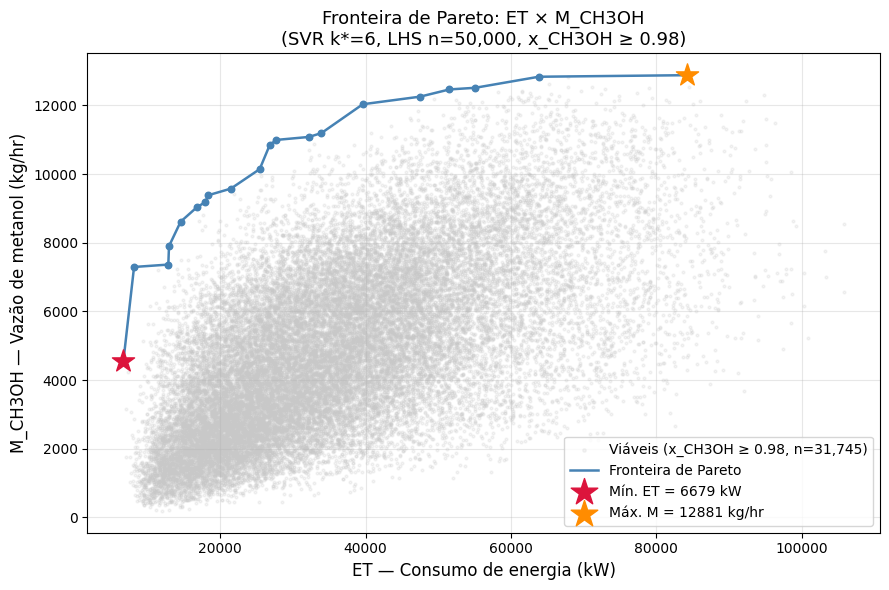

Salvo: ./6.3_pareto_ET_M.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

# Todos os pontos viáveis em cinza claro
ax.scatter(ET_feas, M_feas,
           c="#c8c8c8", alpha=0.20, s=4,
           label=f"Viáveis (x_CH3OH ≥ {PUREZA_LIMIAR}, n={n_viavel:,})")

# Fronteira de Pareto
ax.plot(df_pareto["ET"], df_pareto["M_CH3OH"],
        color="steelblue", linewidth=1.8, zorder=3, label="Fronteira de Pareto")
ax.scatter(df_pareto["ET"], df_pareto["M_CH3OH"],
           color="steelblue", s=22, zorder=4)

# Extremo mínimo ET
idx_min_ET = df_pareto["ET"].idxmin()
p_minET = df_pareto.loc[idx_min_ET]
ax.scatter(p_minET["ET"], p_minET["M_CH3OH"],
           marker="*", s=280, color="crimson", zorder=5,
           label=f"Mín. ET = {p_minET['ET']:.0f} kW")

# Extremo máximo M_CH3OH
idx_max_M = df_pareto["M_CH3OH"].idxmax()
p_maxM = df_pareto.loc[idx_max_M]
ax.scatter(p_maxM["ET"], p_maxM["M_CH3OH"],
           marker="*", s=280, color="darkorange", zorder=5,
           label=f"Máx. M = {p_maxM['M_CH3OH']:.0f} kg/hr")

ax.set_xlabel("ET — Consumo de energia (kW)", fontsize=12)
ax.set_ylabel("M_CH3OH — Vazão de metanol (kg/hr)", fontsize=12)
ax.set_title("Fronteira de Pareto: ET × M_CH3OH\n"
             f"(SVR k*=6, LHS n={N:,}, x_CH3OH ≥ {PUREZA_LIMIAR})", fontsize=13)
ax.legend(fontsize=10, markerscale=1.2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = f"{OUT}/6.3_pareto_ET_M.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvo: {fig_path}")

## Seção 7 — Resumo e validação

Checklist de validação (D-E6-06 a D-E6-09):

- **CSV gerado** com ao menos 10 soluções não dominadas, sem NaN.
- **Pureza verificada**: todas as soluções satisfazem x_CH3OH ≥ 0.98 (ou 0.95 se ajuste D-E6-06 foi acionado).
- **Figura gerada** com extremos marcados e legenda.
- **Correlação ET × M**: esperada positiva ao longo da fronteira — para obter mais metanol é necessário mais energia (trade-off produção vs. eficiência energética).
- **Reprodutibilidade**: seed=42 garante mesmo resultado em qualquer execução.

In [ ]:
print("=== VALIDAÇÃO ===")
print(f"Soluções Pareto:      {len(df_pareto)} (mín. exigido: 10)")
print(f"NaN no CSV:           {df_pareto.isna().sum().sum()}")
print(f"Pureza mín.:          {df_pareto['x_CH3OH'].min():.5f} (limiar: {PUREZA_LIMIAR})")
print(f"Corr. ET×M:           {corr_ET_M:.4f} (esperado > 0)")
print(f"Extremo Mín. ET:      ET={p_minET['ET']:.1f} kW, M={p_minET['M_CH3OH']:.1f} kg/hr")
print(f"Extremo Máx. M:       ET={p_maxM['ET']:.1f} kW, M={p_maxM['M_CH3OH']:.1f} kg/hr")
print()
print("Inputs do ponto Mín. ET:")
print(p_minET[["T1","RRC1","BRC1","RRC2","BRC2","RFF"]].to_string())
print()
print("Inputs do ponto Máx. M_CH3OH:")
print(p_maxM[["T1","RRC1","BRC1","RRC2","BRC2","RFF"]].to_string())